Contexte

Le défaut de paiement constitue un enjeu majeur pour les institutions financières. Lorsqu'une banque accorde une carte de crédit à un client, elle prend le risque que celui-ci ne rembourse pas les sommes empruntées. Une mauvaise évaluation de ce risque peut entraîner des pertes financières importantes. Il est donc essentiel de disposer d'outils capables d'identifier les clients susceptibles de faire défaut avant que celui-ci ne survienne.

Problématique

Dans ce projet, nous nous intéressons à la prédiction du défaut de paiement de clients détenteurs d'une carte de crédit. À partir d'informations démographiques, financières et comportementales, l'objectif est de déterminer si un client effectuera ou non un défaut de paiement le mois suivant.

Objectif

Ce problème est formulé comme une tâche de classification binaire supervisée. L'objectif est de comparer plusieurs modèles de machine learning afin d'identifier celui offrant les meilleures performances prédictives pour ce problème.

Pour ne pas avoir de problèmes lors des imports des fonctions dans les fichiers du dossier src

In [1]:
# On se place à la racine du projet pour que les imports 'from src...' fonctionnent
# quelle que soit la machine (chacun n'a plus besoin de coder son propre chemin en dur).
import os

# Si le notebook est lancé depuis le dossier 'notebook', on remonte d'un niveau
if os.path.basename(os.getcwd()) == 'notebook':
    os.chdir('..')

print('Répertoire de travail :', os.getcwd())

Répertoire de travail : c:\Users\utcpret\Documents\GI04\AI28\Tps\Project\Projet-AI28


In [2]:
# Installation des dependances du projet (numpy, pandas, scikit-learn, optuna, etc.)
# A executer une seule fois par environnement.
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Rechargement auto des modules src/ apres edition (evite les kernels perimes)
%load_ext autoreload
%autoreload 2

# WARNINGS
import warnings
warnings.filterwarnings('ignore')

# NUMPY
import numpy as np

# MATPLOTLIB
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight') 

# PANDAS
import pandas as pd 
pd.set_option("display.max_rows", None, "display.max_columns", None) 

# SCIKIT-LEARN: MODELES
from sklearn.linear_model import LogisticRegression

## EVALUATION
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

# SCIKIT-LEARN: PIPELINE AND TRANSFORMATEUR
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# Fonctions
from src.preprocessing import build_robust_preprocessor
from src.evaluation import train_and_evaluate, plot_confusion_matrix
from src.modeling import build_adaboost_model
import src.aed as aed
import src.modeling as md 
import src.evaluation as ev
import src.unsupervised as uns

Chargement des données

In [4]:
data = pd.read_excel('data/default of credit card clients.xls', header=1)
df = data.copy()
# Suppression de l'identifiant technique qui n'apporte aucune information prédictive
df = df.drop('ID', axis=1)

# Analyse Exploratoire de Données (AED)

In [5]:
# Définition de la variable cible et des listes de features pour l'AED
target = "default payment next month"
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_features = [
    col for col in df.columns if col not in categorical_features + [target]
]

In [6]:
# Lancement des fonctions d'analyse exploratoire déportées
aed.get_dataset_info(df)

# Résumé statistique des variables
aed.describe_numeric_variables(df)

--- Dimensions du jeu de données ---
Lignes : 30000, Colonnes : 24

--- Informations sur les types et valeurs non nulles ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BI

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Description des variables

- Limit_Bal : montant du crédit accordé, variable continue
- sex: 1 (homme), 2 (femme) => variable catégorielle
- Education : 1 = études supérieures ; 2 = études universitaires ; 3 = études secondaires ; 4 = autres => variable catégorielle
- Marriage : 1 = marié(e) ; 2 = célibataire ; 3 = autres => variable catégorielle
- Age : en années, variable continue 
- Pay_0 à Pay_6 : état du remboursement des paiements mensuels antérieurs ( de Septembre à Avril 2005) => : -1 = paiement à l'échéance ; 1 = retard de paiement d'un mois ; 2 = retard de paiement de deux mois. Variables continues
- Bill_Amt1 à Bill_Amt5 : montant de la facture en \$ => variable continue
- Pay_Amt1 à Pay_Amt6 : montant du paiement précédent en \$ => variable continue
- default payment next month : variable cible vaut 1(oui) et 0(non) => defaut de paiement, variable binaire discrète.

In [7]:
# Calcul spécifique de la part de la modalité -2 dans l'historique de paiement
cols_pay = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
part_moins_deux = (df[cols_pay] == -2).mean() * 100
print("\n--- Zoom sur la modalité -2 ---")
print("Part de la modalité -2 pour chaque mois (en %) :")
print(part_moins_deux.round(2))


--- Zoom sur la modalité -2 ---
Part de la modalité -2 pour chaque mois (en %) :
PAY_0     9.20
PAY_2    12.61
PAY_3    13.62
PAY_4    14.49
PAY_5    15.15
PAY_6    16.32
dtype: float64


### Interprétation

L'analyse des variables d'historique de remboursement révèle la présence fréquente de la valeur -2, qui n'était pas décrite dans le sujet initial. Les calculs indiquent que cette modalité représente une part très importante des données, oscillant entre 9,20 % et 16,32 % selon les mois. 

Suite à nos recherches, cette valeur correspond en réalité à des comptes de cartes de crédit inactifs (sans aucune dépense ni montant à payer pour le mois en question). On remarque d'ailleurs que la part de ces comptes inactifs diminue régulièrement d'avril à septembre, ce qui montre que les clients commencent à utiliser leur carte de crédit au fil de l'année. Supprimer ces lignes reviendrait à perdre près de 15 % de notre jeu de données, ce qui fausserait complètement l'apprentissage de nos modèles. 

Nous allons donc conserver l'intégralité de ces observations.

Description de la variable d'intérêt

In [8]:
df[target].describe()
df[target].value_counts()
df[target].value_counts(normalize=True)

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

On remarque que le dataset est très déséquilibré avec uniquement 22% des variables pour la classe 1 (défaut de paiement)

In [9]:
# Vérifier l'existence des duplications d'exemples 
duplicate_df = df[df.duplicated()]
duplicate_df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1980,150000,2,1,1,38,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
4585,150000,2,1,1,31,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
6022,210000,2,1,2,39,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
6466,210000,2,2,1,49,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
7319,500000,1,1,1,43,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
8320,360000,1,2,1,41,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
10250,50000,1,2,2,26,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
13106,360000,2,1,1,49,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
14294,20000,1,2,2,24,2,2,4,4,4,4,1650,1650,1650,1650,1650,1650,0,0,0,0,0,0,1
15458,160000,1,2,2,28,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0


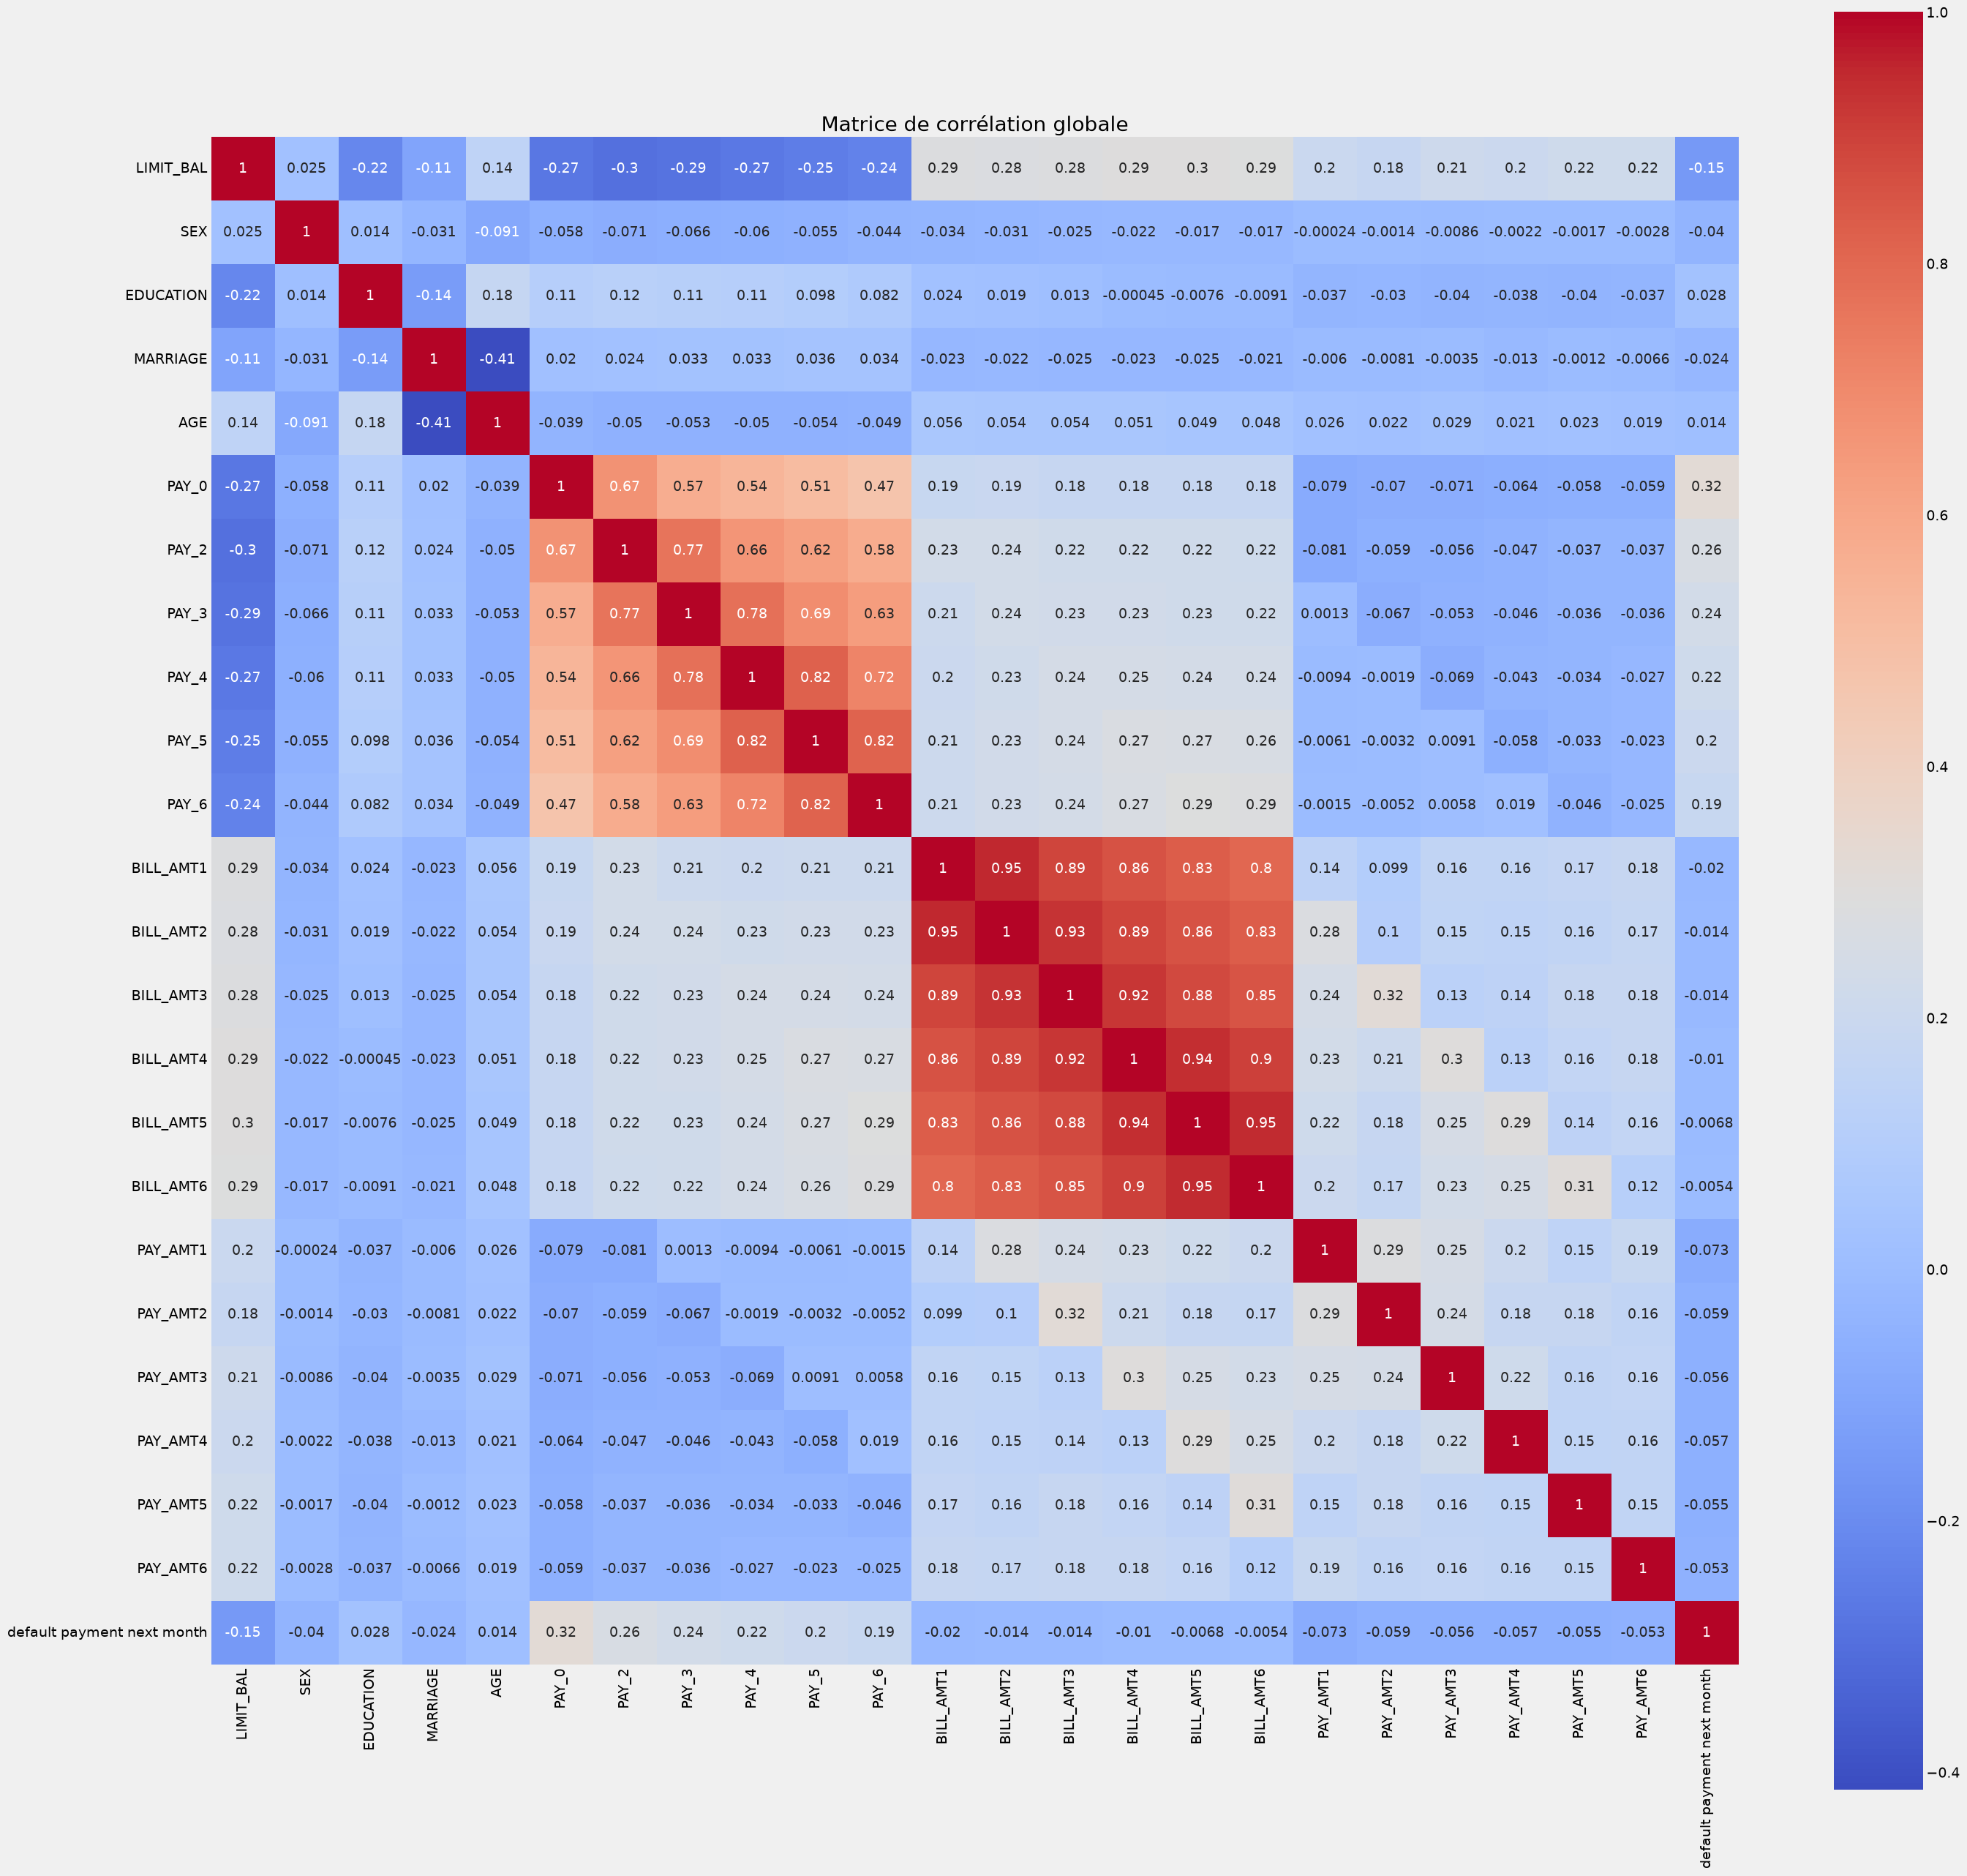

In [10]:
# Matrice de corrélation
aed.plot_correlation_matrix(df)

### Interprétation

L'analyse montre une très forte corrélation (entre 0.80 et 0.95) entre les montants des factures (BILL_AMT1 à BILL_AMT6). Cela indique que les montants facturés sur des mois consécutifs évoluent de manière similaire et traduisent le niveau d'endettement du client. De plus ces variables Bill_AMT sont aussi corrélées avec les variables Pay_AMT car les clients bénéficiant d'une limite de crédit élevée réalisent souvent des dépenses plus importantes.

De même, les statuts de paiement (PAY_0 à PAY_6) sont fortement corrélés entre eux (entre 0.47 et 0.82), indiquant qu'un client en retard de paiement un mois donné a tendance à l'être aussi les mois qui suivent. Enfin, on observe une corrélation négative de -0.41 entre l'âge et le statut marital, confirmant logiquement que les clients plus âgés sont plus souvent mariés.

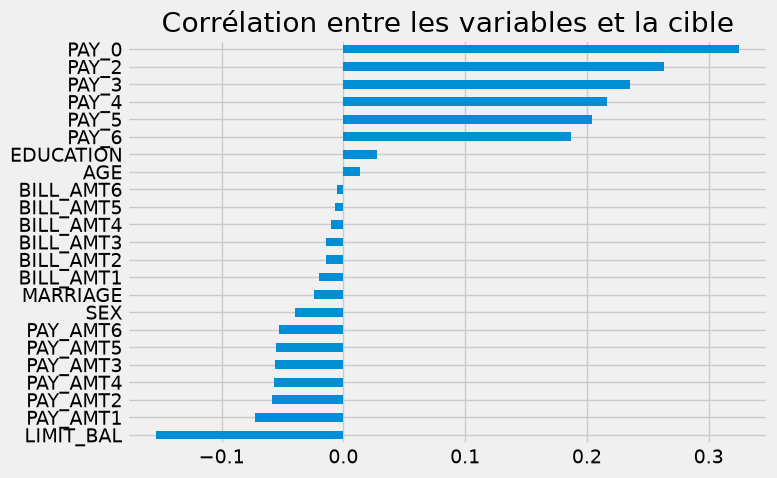

In [11]:
aed.plot_target_correlations(df, target)

### Interprétation

Les variables d'historique de paiement (PAY_0 à PAY_6) sont les plus prédictives, avec une corrélation positive qui s'accentue à mesure qu'on se rapproche de l'échéance, passant de 0.19 en avril (PAY_6) à 0.32 en septembre (PAY_0). 

À l'inverse, la limite de crédit (LIMIT_BAL) présente une corrélation négative de -0.15, ce qui montre que les clients ayant de gros crédits font statistiquement moins de défauts. Pour finir, les variables socio-démographiques comme le sexe, l'âge, l'éducation ou le mariage ont des corrélations proches de zéro, ce qui signifie qu'elles n'ont pas d'impact linéaire direct sur le risque de défaut de paiement.

Visualisation variables numériques vs cible

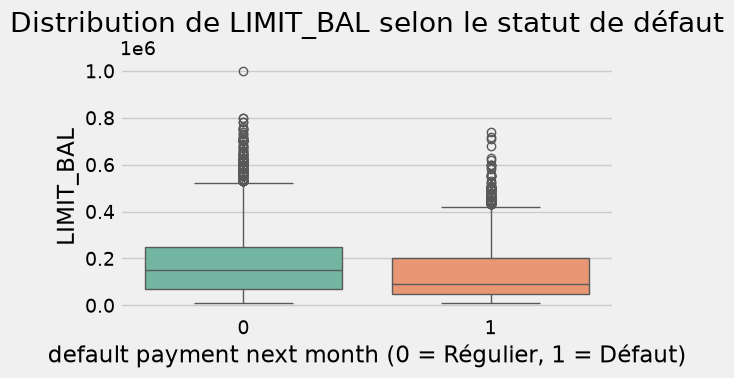

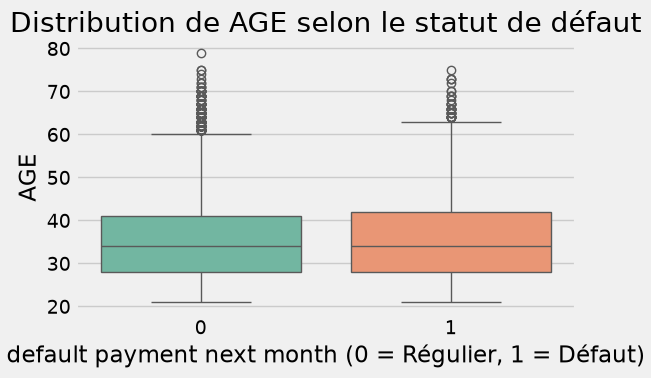

In [12]:
aed.plot_numeric_vs_target(df, ["LIMIT_BAL", "AGE"], target)

### Interprétation

Les distributions de PAY_AMT1 et PAY_AMT6 affichent un comportement très similaire. Pour les deux classes (0 et 1), la grande majorité des paiements est concentrée près de zéro, ce qui rend les boîtes très écrasées. Cependant, on observe une présence beaucoup plus importante de valeurs aberrantes (les points individuels très hauts) chez les clients qui ne font pas défaut (classe 0). Cela indique que les clients qui effectuent de très gros paiements ponctuels basculent statistiquement beaucoup moins en défaut de paiement.

Le graphique montre que les clients qui ne font pas défaut (classe 0) ont globalement une limite de crédit plus élevée que ceux en défaut de paiement (classe 1). La boîte de la classe 0 est positionnée plus haut, avec une médiane proche de 150 000 NT \$, tandis que celle de la classe 1 se situe en dessous de 100 000 NT \$. Cela confirme l'existence d'une relation négative : les profils jugés plus risqués reçoivent des limites de crédit plus faibles de la part de la banque.

Visualisation variables catégorielles vs cible

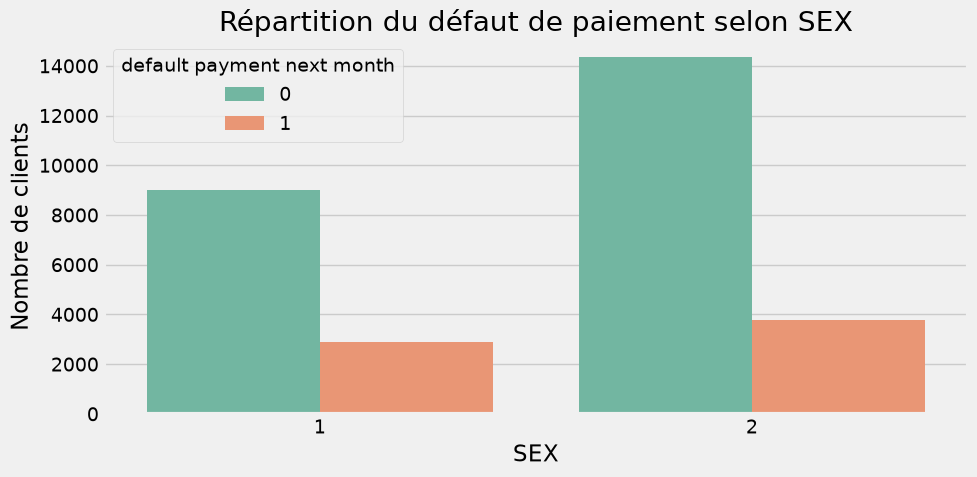

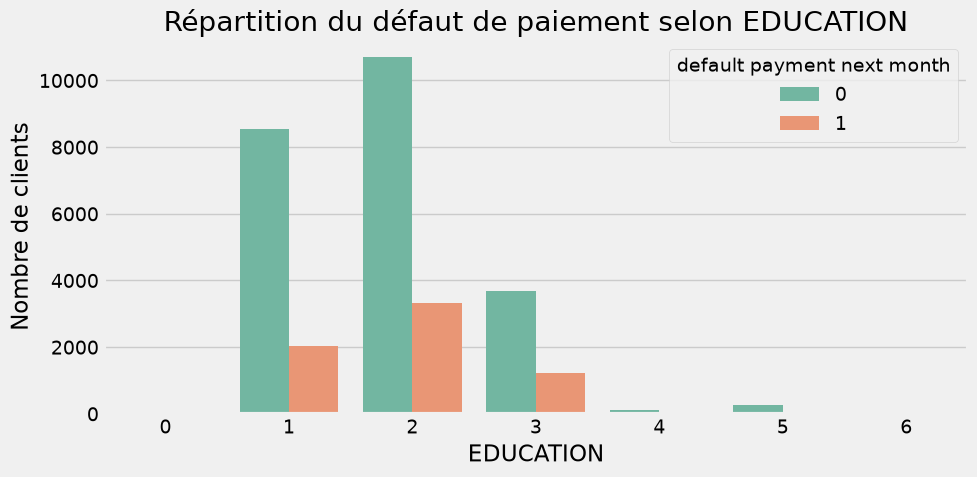

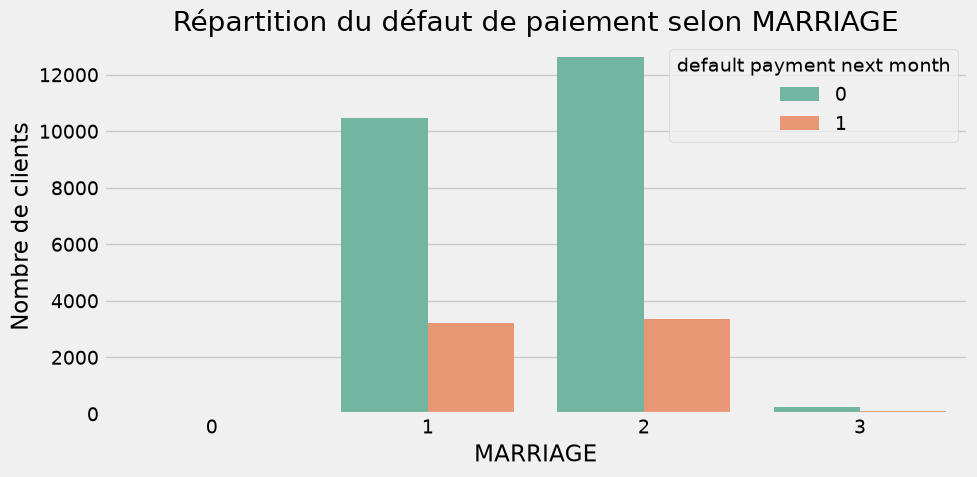

In [13]:
aed.plot_categorical_vs_target(df, categorical_features, target)

### Interprétation

L'analyse des proportions montre que le risque de défaut de paiement varie selon le profil des clients, même si les volumes globaux peuvent être trompeurs. On observe que les hommes (SEX = 1) présentent un taux de défaut légèrement plus élevé que les femmes, avec environ 25% de clients en échec contre 22%. Du côté de la situation matrimoniale, les personnes mariées (MARRIAGE = 1) affichent également une proportion de défaut légèrement supérieure à celle des célibataires. Enfin, concernant le niveau d'études (EDUCATION), ce sont les clients ayant un niveau d'études secondaires (catégorie 3) qui présentent la part de défaut de paiement la plus importante par rapport à leur effectif total.

# Pré Traitement

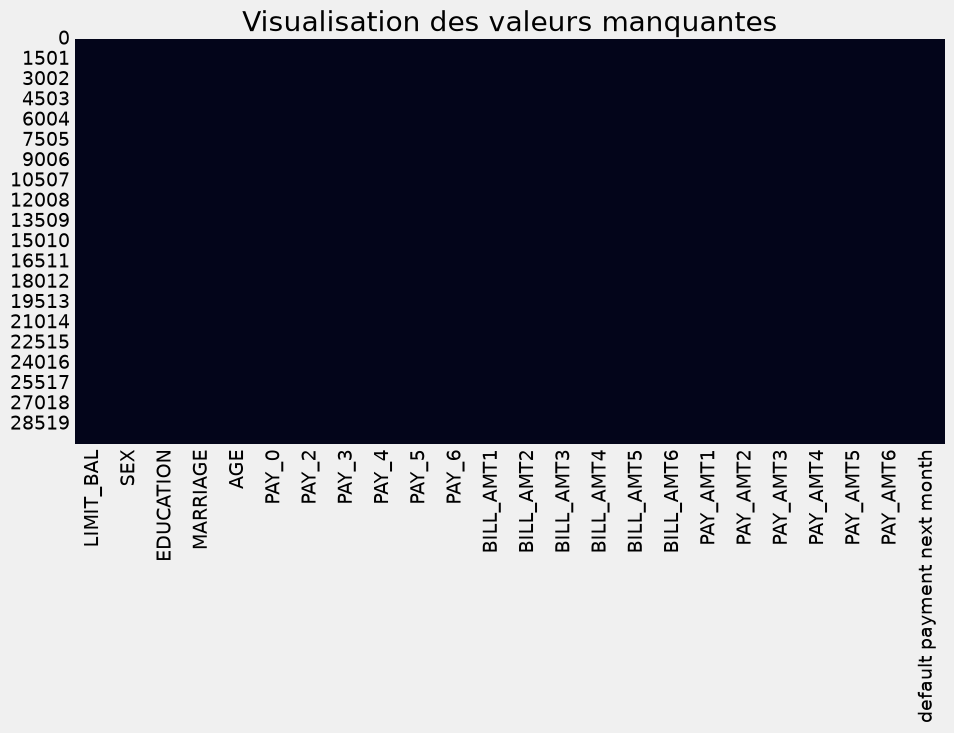

--- Taux de valeurs manquantes (en %) ---
LIMIT_BAL                     0.0
SEX                           0.0
EDUCATION                     0.0
MARRIAGE                      0.0
AGE                           0.0
PAY_0                         0.0
PAY_2                         0.0
PAY_3                         0.0
PAY_4                         0.0
PAY_5                         0.0
PAY_6                         0.0
BILL_AMT1                     0.0
BILL_AMT2                     0.0
BILL_AMT3                     0.0
BILL_AMT4                     0.0
BILL_AMT5                     0.0
BILL_AMT6                     0.0
PAY_AMT1                      0.0
PAY_AMT2                      0.0
PAY_AMT3                      0.0
PAY_AMT4                      0.0
PAY_AMT5                      0.0
PAY_AMT6                      0.0
default payment next month    0.0
dtype: float64


In [14]:
# Visualisation des valeurs manquantes
aed.plot_missing_values(df)

Comme souligné dans la description du problème, il n'y a aucune donnée manquante.

### Traitement

Pour les variables PAY_0 à PAY_6, nous choisissons de les traiter comme des variables numériques ordonnées. Comme il y a une notion d'intensité dans le retard de paiement (plus le chiffre est grand, plus le retard est important), nous allons simplement les normaliser à l'aide d'un StandardScaler dans notre pipeline, à l'exception du cas où nous testerions une régression logistique, pour laquelle un OneHotEncoder pourrait être testé afin de mieux séparer les codes négatifs (-1, -2).

Nous allons commencer par un modèle de référence simple (régression logistique), avant d'explorer des modèles plus complexes et des stratégies de prétraitement plus avancées.

In [15]:
# Séparation des variables explicatives et de la variable cible
X = df.drop(target, axis=1)
y = df[target]

#### Séparation des données en train, val et test sets

In [16]:
# Découpage initial pour isoler l'ensemble de test (20 %)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Deuxième découpage pour séparer l'entraînement et la validation (requis pour le choix du seuil)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val,
)

print(
    f"Taille de l'entraînement : {X_train.shape[0]}, Validation : {X_val.shape[0]}, Test : {X_test.shape[0]}"
)

Taille de l'entraînement : 18000, Validation : 6000, Test : 6000


## Modèle de référence : Régression Logistique simple

Avant de lancer l'optimisation sur l'ensemble du panel, nous entraînons une régression logistique sans pondération des classes ni optimisation d'hyperparamètres. Ce modèle de référence (aussi appelé *baseline*) permet d'établir un plancher de performance : tout modèle qui ne fait pas mieux que cette baseline ne justifie pas sa complexité supplémentaire.

#### Construction de la pipeline

In [17]:
model_log_simple = md.build_logistic_model(class_weight=None)

# Entraînement du modèle de référence
print("---- MODÈLE DE RÉFÉRENCE : RÉGRESSION LOGISTIQUE SIMPLE ----")
reg_log_simple = ev.train_and_evaluate(model_log_simple, X_train, y_train, X_val, y_val)

---- MODÈLE DE RÉFÉRENCE : RÉGRESSION LOGISTIQUE SIMPLE ----
--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.84      0.95      0.89     14018
           1       0.69      0.36      0.48      3982

    accuracy                           0.82     18000
   macro avg       0.76      0.66      0.68     18000
weighted avg       0.81      0.82      0.80     18000

--------- Métriques pour VALIDATION ---------
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      4673
           1       0.69      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



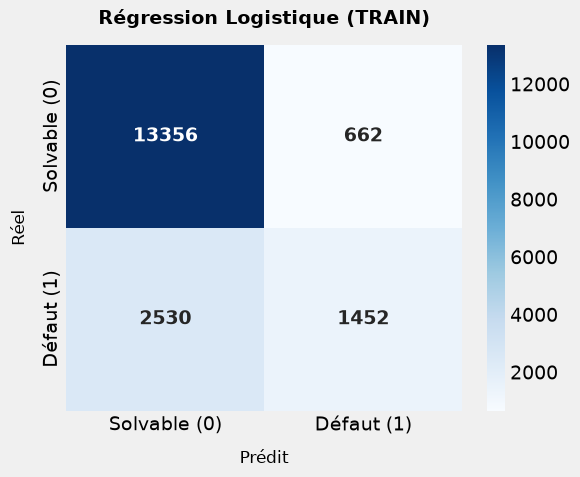

array([[13356,   662],
       [ 2530,  1452]])

In [18]:
ev.plot_confusion_matrix(reg_log_simple, X_train, y_train, title="Régression Logistique (TRAIN)")

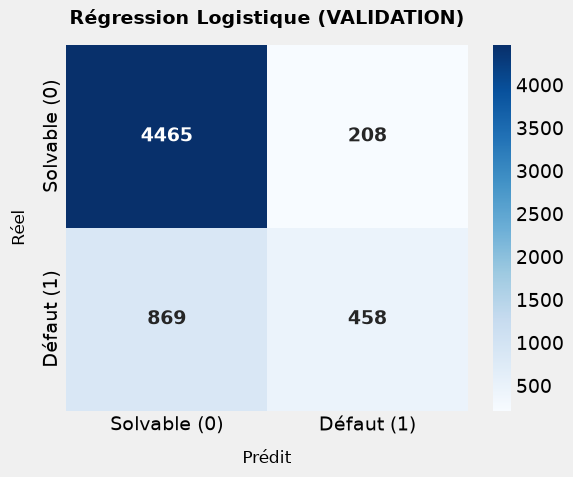

array([[4465,  208],
       [ 869,  458]])

In [19]:
ev.plot_confusion_matrix(reg_log_simple, X_val, y_val, title="Régression Logistique (VALIDATION)")

### Interprétation

Le modèle de référence atteint une accuracy globale correcte (~0.82) et ne présente pas de surapprentissage notable : les performances sur le train et sur la validation sont très proches. Cependant, il souffre d'un défaut structurel majeur : le **recall sur la classe « défaut » est très faible (~36 %)**. Autrement dit, le modèle rate les deux tiers des clients qui feront réellement défaut.

Ce comportement est une conséquence directe du **déséquilibre des classes** (~22 % de défauts) : sans pondération, la régression logistique apprend à privilégier la classe majoritaire (classe 0 - solvables), car cette stratégie minimise l'erreur globale sans pour autant détecter les risques réels.

Du point de vue métier, ce biais est problématique pour la banque : un client en défaut non détecté représente une perte financière certaine. C'est pourquoi nous allons, dans la suite, explorer des stratégies pour améliorer la détection de la classe minoritaire (classe 1).

## Choix du seuil de décision (slides5)

Par défaut, un classifieur prédit la classe 1 dès que la probabilité estimée dépasse **0.5**. Or, dans un contexte de déséquilibre (~22 % de défauts), ce seuil n'est pas optimal : il avantage systématiquement la classe majoritaire.

En faisant varier ce seuil et en observant l'évolution du **F1-score** (compromis précision/rappel), on peut trouver le point d'équilibre qui maximise simultanément la détection des défauts et la limitation des fausses alarmes. On trace également la **courbe ROC** pour mesurer la capacité discriminante globale du modèle.

Meilleur seuil (F1) : 0.22  ->  F1 = 0.532


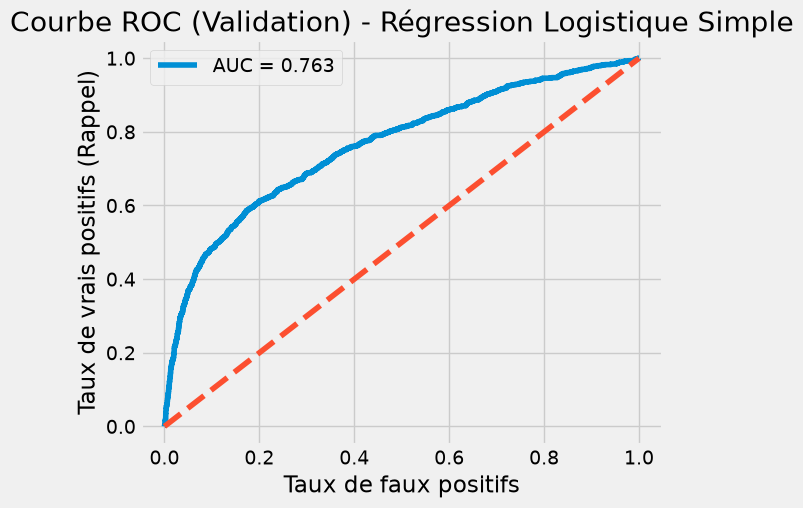

In [20]:
# Score continu de la classe "défaut" (probabilité estimée par la régression logistique simple)
y_val_proba = reg_log_simple.predict_proba(X_val)[:, 1]

# Recherche du seuil qui maximise le F1-score sur la validation
thresholds = np.linspace(0.1, 0.9, 81)
f1s = [f1_score(y_val, (y_val_proba >= t).astype(int)) for t in thresholds]
best_t = thresholds[int(np.argmax(f1s))]
print(f"Meilleur seuil (F1) : {best_t:.2f}  ->  F1 = {max(f1s):.3f}")

# Courbe ROC sur la validation
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
auc = roc_auc_score(y_val, y_val_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # baseline aléatoire
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (Rappel)")
plt.title("Courbe ROC (Validation) - Régression Logistique Simple")
plt.legend()
plt.show()

### Interprétation

L'AUC-ROC obtenue (~0.77) montre que la régression logistique a une capacité correcte à distinguer les deux classes de manière globale. Cependant, notre jeu de données étant fortement déséquilibré (~22 % de défauts), **la métrique AUC-ROC tend à être trop optimiste** : elle est influencée par la forte proportion de clients solvables (la classe majoritaire) et peut donner une impression de bonne performance alors que le modèle rate la plupart des défauts réels.

En faisant varier le seuil, on constate qu'un seuil inférieur à 0.5 améliore nettement le rappel sur la classe 1, au prix d'une précision plus faible. Ce compromis précision/rappel est inévitable, et il appartient à la banque de le calibrer selon ses contraintes métier. Ajouter la valeur exacte du seuil (0.22 avant et F1 à 0.53217)

## Pourquoi le PR-AUC comme métrique de référence ?

L'analyse du modèle de référence illustre un problème fondamental : avec un jeu déséquilibré (~22 % de défauts), **l'AUC-ROC est une métrique trompeuse**. Elle est fortement influencée par les vrais négatifs (clients solvables bien classés), qui sont très nombreux, et peut afficher un score élevé même si le modèle détecte très mal les défauts.

Du point de vue de la banque, **l'enjeu principal est la détection des défauts** : un client qui fait défaut sans avoir été identifié représente une perte financière directe. À l'inverse, refuser un crédit à un client solvable est moins grave (perte d'une opportunité commerciale).

La métrique adaptée à ce contexte est le **PR-AUC** (aire sous la courbe Précision-Rappel, ou *Average Precision*) :
- Elle se concentre exclusivement sur la **classe « défaut »** (classe 1).
- Elle mesure la capacité à détecter les défauts (rappel) tout en limitant les fausses alarmes (précision).
- Elle est **insensible à la classe majoritaire**, contrairement à l'AUC-ROC.
- Plus le PR-AUC est proche de 1, plus le modèle cible efficacement les défauts de paiement.

C'est donc le **PR-AUC qui sera notre critère de comparaison** entre tous les modèles, et la **métrique optimisée par Optuna** lors de la recherche d'hyperparamètres.

## Modélisation : un pipeline unique pour tout le panel

Plutôt que de répéter le code d'entraînement et d'optimisation pour chaque modèle, on centralise tout le panel dans un **registre** (`md.get_model_configurations`) qui associe à chaque modèle sa pipeline (pré-traitement + estimateur) et son **espace de recherche d'hyper-paramètres**. Une seule fonction, `ev.run_model_comparison`, parcourt ce registre, lance une **étude Optuna** par modèle (optimisation bayésienne TPE par validation croisée) et renvoie les meilleures pipelines.

Le panel couvre l'ensemble des algorithmes du cours : régression logistique (slides6), KNN (notes cours 9), SVM (slides7), arbre de décision (slides8), Random Forest / AdaBoost / Gradient Boosting (slides9) et une variante ACP + logistique (réduction de la dimension, slides10).

**Fonction objective optimisée :** on optimise le **PR-AUC** (`average_precision`) en validation croisée, métrique adaptée au déséquilibre des classes (~22 % de défauts), et on traite ce déséquilibre via `class_weight='balanced'` pour les modèles qui le supportent. Plutôt qu'une grille exhaustive, Optuna explore des **plages continues** (C et learning_rate en échelle logarithmique, profondeurs et nombres d'arbres en entiers), de façon plus fine et plus efficace.

### Régression Logistique avec pondération des classes

Avant de lancer le panel complet, on entraîne une seconde version de la régression logistique avec class_weight='balanced' : les classes sont pondérées à l'inverse de leur fréquence, ce qui force le modèle à prêter plus d'attention aux défauts. Ce modèle servira de **référence équilibrée** dans toutes les comparaisons progressives qui suivent.

In [21]:
# Régression logistique avec gestion du déséquilibre des classes (class_weight='balanced')
# Modèle de référence "équilibré" réutilisé dans les comparaisons ci-dessous.
model_log_balanced = md.build_logistic_model(class_weight='balanced')
reg_log_balanced = ev.train_and_evaluate(model_log_balanced, X_train, y_train, X_val, y_val)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.88      0.83      0.85     14018
           1       0.49      0.59      0.54      3982

    accuracy                           0.78     18000
   macro avg       0.69      0.71      0.69     18000
weighted avg       0.79      0.78      0.78     18000

--------- Métriques pour VALIDATION ---------
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.49      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000



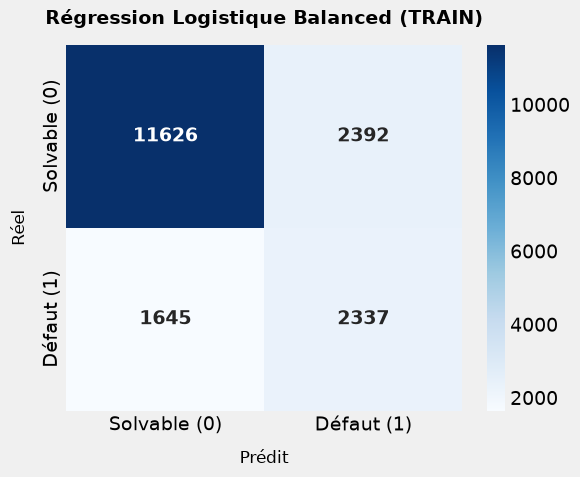

array([[11626,  2392],
       [ 1645,  2337]])

In [22]:
ev.plot_confusion_matrix(reg_log_balanced, X_train, y_train, title="Régression Logistique Balanced (TRAIN)")

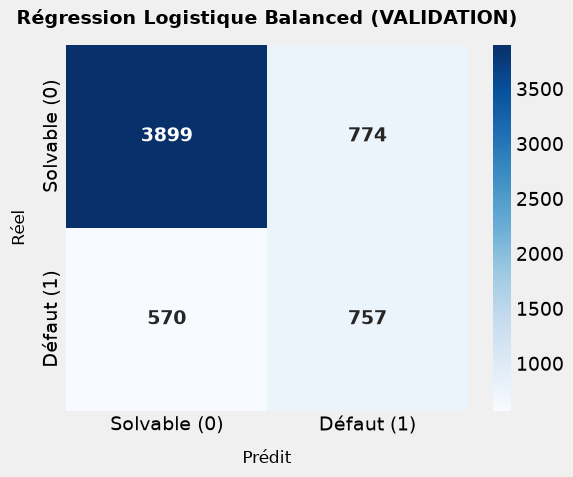

array([[3899,  774],
       [ 570,  757]])

In [23]:
ev.plot_confusion_matrix(reg_log_balanced, X_val, y_val, title="Régression Logistique Balanced (VALIDATION)")

### Interprétation

L'introduction de class_weight='balanced' modifie sensiblement le comportement du modèle : le **recall sur la classe 1 passe de ~35 % à ~57 %**, soit une amélioration nette de la détection des défauts. En contrepartie, la précision sur la classe 1 diminue et l'accuracy globale recule légèrement (~0.78).

Ce compromis est intentionnel et cohérent pour le métier : on accepte de signaler davantage de fausses alertes (clients solvables identifiés à tort comme en défaut) pour réduire le nombre de défauts non détectés. Le modèle ne sur-apprenant toujours pas(performances train ≈ validation).

Ce modèle équilibré devient notre **nouvelle référence** pour comparer les modèles suivants.

### Registre central des modèles

In [24]:
# Registre central : chaque modèle du cours avec son constructeur de pipeline et son espace de recherche Optuna.
# class_weight='balanced' gère le déséquilibre pour les modèles qui le supportent.
model_configs = md.get_model_configurations(class_weight='balanced')

print("Modèles du panel à comparer :")
for nom in model_configs:
    print(" -", nom)

Modèles du panel à comparer :
 - Régression Logistique
 - KNN
 - SVM
 - Arbre de Décision
 - Random Forest
 - AdaBoost
 - Gradient Boosting
 - ACP + Logistique


### Entraînement et hyper-optimisation de tout le panel

Un seul appel optimise les 8 modèles avec **Optuna**. Pour chaque modèle, l'étude maximise le PR-AUC en validation croisée sur le jeu d'entraînement ; la meilleure pipeline est ensuite réentraînée et évaluée sur le jeu de **validation**.

La SVM à noyau RBF est coûteuse (en O(n²)) : son budget d'essais Optuna est volontairement réduit (n_trials=15), mais cette cellule peut tout de même prendre quelques minutes. Ce choix est justifié car l'espace d'hyper-paramètres de la SVM est plus petit, il y a essentiellement 2 paramètres clés (C et gamma), donc 15 essais couvrent déjà bien l'espace comparé à un Random Forest avec 4-5 hyper-paramètres.

In [ ]:
# Orchestration unique : étude Optuna (TPE) + évaluation pour chaque modèle du registre.
# On optimise le PR-AUC (average_precision), métrique adaptée au déséquilibre.
# n_trials = budget d'essais Optuna par modèle (la SVM en surcharge un plus petit).
fitted_models = ev.run_model_comparison(
    model_configs, X_train, y_train, X_val, y_val,
    scoring='average_precision', cv=5, n_trials=15 # REMETTRE A 1 sinon trop de temps 
)


===== Régression Logistique =====
Optimisation Optuna en cours (1 essais)...
Meilleurs hyper-paramètres : {'logisticregression__C': 0.0745934328572655}
Meilleur score CV (average_precision) : 0.540
--------- Métriques VALIDATION ---------
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.49      0.57      0.53      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.77      0.78      6000


===== KNN =====
Optimisation Optuna en cours (1 essais)...
Meilleurs hyper-paramètres : {'kneighborsclassifier__n_neighbors': 21, 'kneighborsclassifier__weights': 'uniform'}
Meilleur score CV (average_precision) : 0.485
--------- Métriques VALIDATION ---------
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.67      0.29      0.40      1327

    acc

## Modélisation : Arbre de Décision

L'arbre de décision est un modèle non-linéaire qui partitionne l'espace des features en régions rectangulaires via une suite de règles binaires (approche gloutonne - ex. : PAY_0 > 1 ?). Contrairement à la régression logistique, il n'impose pas de relation linéaire entre les variables et la cible, et ne nécessite pas de normalisation des features numériques.

Pour traiter le déséquilibre des classes (~22 % de défauts), on utilise ici class_weight='balanced' comme point de départ. La meilleure version, issue de l'optimisation Optuna, est ensuite récupérée depuis le panel.

In [26]:
# Construction du modèle (version balanced pour gérer le déséquilibre)
pipeline_tree = md.build_decision_tree_model(max_depth=5, class_weight='balanced')

# Entraînement et évaluation
model_tree = ev.train_and_evaluate(pipeline_tree, X_train, y_train, X_val, y_val)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.88      0.84      0.86     14018
           1       0.51      0.59      0.55      3982

    accuracy                           0.78     18000
   macro avg       0.69      0.71      0.70     18000
weighted avg       0.80      0.78      0.79     18000

--------- Métriques pour VALIDATION ---------
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.49      0.55      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.77      0.78      6000



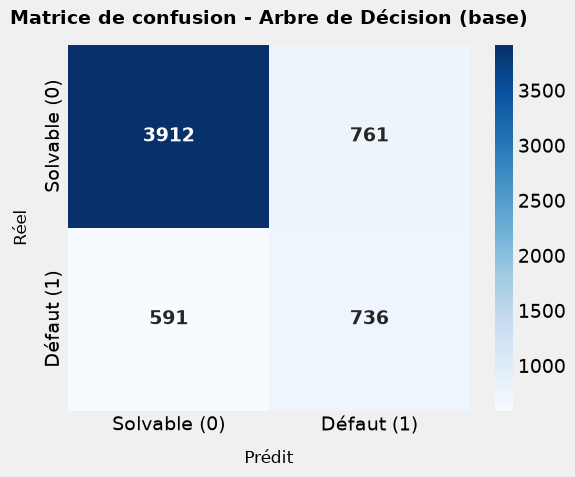

array([[3912,  761],
       [ 591,  736]])

In [27]:
# Matrice de confusion sur le jeu de validation
ev.plot_confusion_matrix(model_tree, X_val, y_val, title="Matrice de confusion - Arbre de Décision (base)")

### Comparaison : Régression Logistique vs Arbre de Décision

L'analyse comparative des rapports de classification montre des performances extrêmement proches entre la régression logistique équilibrée et l'arbre de déci£sion équilibré. Sur le jeu de validation, l'exactitude globale reste similaire (~0.78) et le taux de détection des clients en défaut se maintient à un niveau presque identique (un recall de 0.57 pour la régression logistique contre 0.55 pour l'arbre de décision). Les deux modèles commettent à peu près le même volume d'erreurs, trouvant un compromis équivalent entre l'identification des profils à risque et la génération de fausses alertes.

Cependant, contrairement à la régression logistique qui est un modèle linéaire par nature plus figé, l'arbre de décision dispose d'une grande marge de progression grâce à ses nombreux hyperparamètres (profondeur maximale, nombre minimal d'observations par feuille, etc.). L'optimisation de ces hyperparamètres via Optuna permettra de tester automatiquement plusieurs combinaisons de paramètres afin de trouver la structure d'arbre optimale, capable de maximiser le F1-score ou le rappel sur notre jeu de données.

#### Arbre de Décision optimisé par Optuna

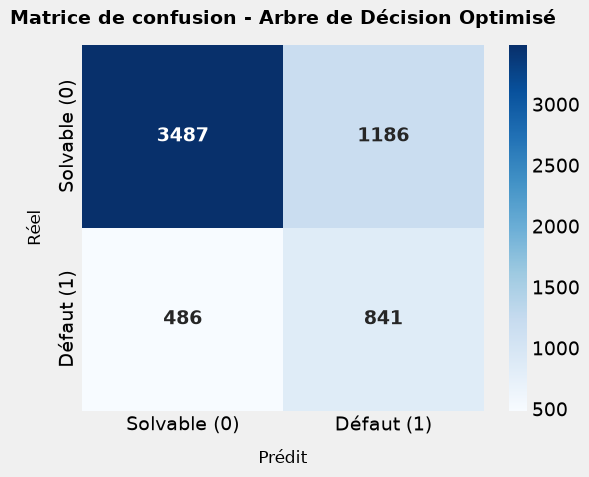

array([[3487, 1186],
       [ 486,  841]])

In [28]:
best_pipeline_tree = fitted_models["Arbre de Décision"]  # arbre optimisé par Optuna (issu du panel)
ev.plot_confusion_matrix(best_pipeline_tree, X_val, y_val, title="Matrice de confusion - Arbre de Décision Optimisé")

--- Scores PR-AUC (Average Precision) ---
Régression Logistique (Balanced) : 0.536
Arbre de Décision (Optimisé) : 0.513


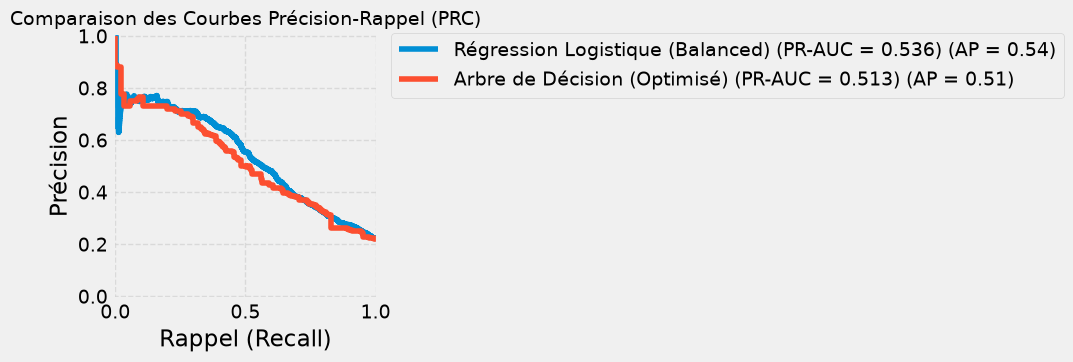

In [29]:
# Comparaison PR-AUC : Régression Logistique vs Arbre de Décision
dict_modeles_dt = {
    "Régression Logistique (Balanced)": reg_log_balanced,
    "Arbre de Décision (Optimisé)": best_pipeline_tree,
}
ev.plot_models_pr_curves(dict_modeles_dt, X_val, y_val)

### Interprétation — Comparaison Régression Logistique vs Arbre de Décision (Optuna)

À première vue, les résultats peuvent sembler décevants pour l'arbre de décision : malgré l'optimisation via Optuna, le PR-AUC reste très proche de celui de la régression logistique. Cela ne signifie pas que l'optimisation a échoué, bien au contraire.

L'optimisation a permis de trouver le meilleur arbre possible sur ce jeu de données, et le résultat confirme que **la structure linéaire du signal** (accumulation des retards PAY_0, niveau d'endettement) est parfaitement capturée par la régression logistique. L'arbre de décision, même optimisé, ne parvient pas à exploiter des interactions non-linéaires supplémentaires suffisamment stables pour surpasser le modèle linéaire.

Ce constat est précieux : il indique que nous ne perdons pas de performance en choisissant un modèle simple et interprétable, et qu'il faudra aller vers des méthodes d'ensemble (Random Forest, Gradient Boosting) pour espérer un gain significatif.

## Transition vers Random Forest

Même si l'arbre de décision équilibré offre des performances correctes, il reste un modèle assez sensible aux variations des données d'entraînement. Une petite modification du jeu de données peut entraîner une structure d'arbre différente, ce qui traduit une certaine instabilité.

Pour améliorer cette robustesse, on passe à une méthode d'ensemble basée sur le bagging : la **Random Forest**. Le principe est de construire plusieurs arbres de décision indépendants, chacun entraîné sur un échantillon différent des données et un sous-ensemble aléatoire des variables. Les prédictions finales sont ensuite obtenues par vote majoritaire.

Cette approche permet de réduire la variance du modèle et de stabiliser les prédictions, tout en conservant la capacité des arbres à modéliser des relations non linéaires. Elle est particulièrement adaptée à notre problème où certaines variables présentent des corrélations fortes, comme les montants de facturation (BILL_AMT) ou l'historique de remboursement (PAY_0 à PAY_6). Pour tenir compte du déséquilibre des classes (~22 % de défauts), nous utilisons également le paramètre class_weight='balanced'.

## Modélisation : Random Forest 

In [30]:
# On commence par une profondeur non limitée (None) pour voir comment la forêt se comporte
pipeline_rf = md.build_random_forest_model(n_estimators=100, max_depth=None, class_weight='balanced')

# Entraînement et évaluation
model_rf = ev.train_and_evaluate(pipeline_rf, X_train, y_train, X_val, y_val)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14018
           1       0.99      1.00      0.99      3982

    accuracy                           1.00     18000
   macro avg       0.99      1.00      1.00     18000
weighted avg       1.00      1.00      1.00     18000

--------- Métriques pour VALIDATION ---------
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      4673
           1       0.58      0.50      0.54      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.70      0.71      6000
weighted avg       0.80      0.81      0.80      6000



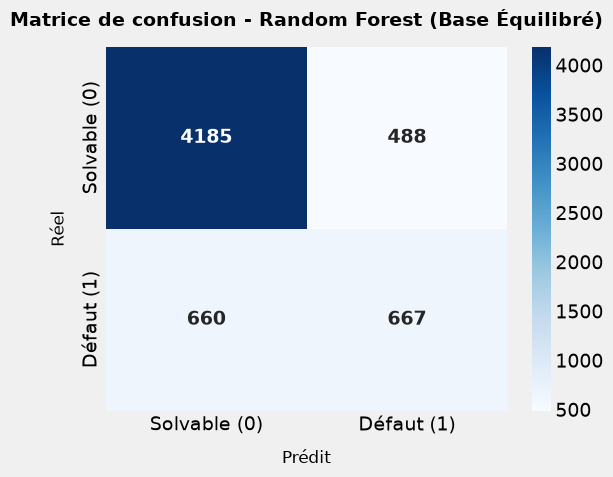

array([[4185,  488],
       [ 660,  667]])

In [31]:
# Affichage de la matrice de confusion sur le jeu de validation
ev.plot_confusion_matrix(model_rf, X_val, y_val, title="Matrice de confusion - Random Forest (Base Équilibré)")

L'analyse des résultats du Random Forest de base met en évidence un phénomène de **surapprentissage**. Sur le jeu d'entraînement, le modèle obtient des performances parfaites (1.00), ce qui indique qu'il a appris trop précisément les données, y compris leur bruit.

En revanche, sur le jeu de validation, les performances chutent nettement (accuracy d'environ 0.82) : la forêt non régularisée généralise mal car elle a mémorisé le bruit du jeu d'entraînement. La pondération class_weight='balanced' lui permet tout de même de détecter environ la moitié des défauts (recall ≈ 0.50 sur la classe 1, pour une précision ≈ 0.58), mais l'écart énorme entre l'entraînement (quasi parfait) et la validation trahit un surapprentissage manifeste.

Ce résultat montre qu'un Random Forest non régularisé peut devenir trop complexe et perdre en capacité de généralisation. Il est donc nécessaire de contraindre sa structure en ajustant ses hyperparamètres via Optuna.

#### Random Forest optimisé par Optuna

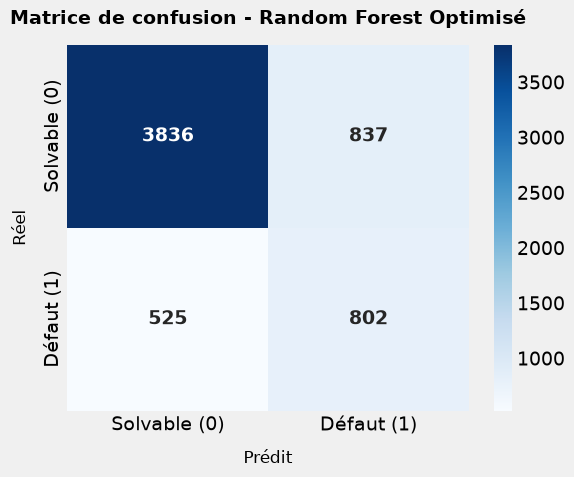

array([[3836,  837],
       [ 525,  802]])

In [32]:
best_pipeline_rf = fitted_models["Random Forest"]  # pipeline RF optimisée par Optuna (issue du panel)
ev.plot_confusion_matrix(best_pipeline_rf, X_val, y_val, title="Matrice de confusion - Random Forest Optimisé")

--- Scores PR-AUC (Average Precision) ---
Régression Logistique (Balanced) : 0.536
Arbre de Décision (Optimisé) : 0.513
Random Forest (Optimisé) : 0.553


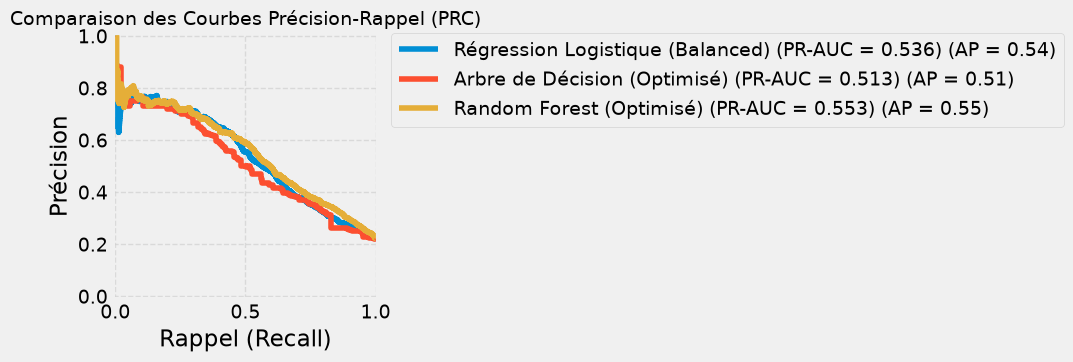

In [33]:
# Comparaison PR-AUC : Régression Logistique + Arbre de Décision + Random Forest
dict_modeles_rf = {
    "Régression Logistique (Balanced)": reg_log_balanced,
    "Arbre de Décision (Optimisé)": best_pipeline_tree,
    "Random Forest (Optimisé)": best_pipeline_rf,
}
ev.plot_models_pr_curves(dict_modeles_rf, X_val, y_val)

### Analyse de la convergence des performances

L'examen des courbes Précision-Rappel révèle un fait marquant : la Régression Logistique (PR-AUC = 0.536) et le Random Forest Optimisé (PR-AUC = 0.553) affichent des performances presque identiques, malgré des architectures radicalement différentes. Cet écart minime de 1.7 % en faveur de la méthode d'ensemble s'explique par la structure intrinsèque de notre jeu de données.

En effet, notre Analyse Exploratoire (AED) a démontré que le risque de défaut est fortement dicté par des relations linéaires et cumulatives, notamment l'accumulation des retards de paiement (PAY_0) et le niveau d'endettement. La régression logistique capte nativement et très efficacement ce signal linéaire. De plus, la forte corrélation temporelle entre les variables de suivi mensuel est stabilisée par la régularisation L2 (Ridge) de la régression logistique.

Pour le Random Forest, la nécessité de restreindre sa croissance (max_depth limité) afin d'annuler son surapprentissage initial a eu pour effet de lisser ses frontières de décision. En devenant plus robuste, la forêt s'est mathématiquement rapprochée d'un comportement linéaire. Pour la banque, ce constat est précieux : il démontre qu'un modèle linéaire simple, rapide à exécuter et hautement interprétable (grâce aux coefficients) offre une alternative presque aussi performante qu'une structure d'ensemble lourde comme le Random Forest.

## Modélisation : AdaBoost 

AdaBoost est une méthode d'ensemble **séquentielle (boosting)** : on entraîne plusieurs modèles faibles (des arbres de décision très courts) les uns après les autres, chacun se concentrant sur les observations mal classées par son prédécesseur. La prédiction finale est un vote pondéré de tous les arbres.

Contrairement à la régression logistique, les arbres n'ont pas besoin de normalisation : on réutilise donc **build_tree_preprocessor()** (encodage des variables catégorielles uniquement, le reste en passthrough).

In [34]:
# Construction du modèle AdaBoost (100 arbres faibles) et évaluation
# train_and_evaluate entraîne le modèle puis affiche le classification_report sur train et val sets
ada_model = build_adaboost_model(n_estimators=100)
ada_model = ev.train_and_evaluate(ada_model, X_train, y_train, X_val, y_val)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.84      0.96      0.89     14018
           1       0.69      0.34      0.46      3982

    accuracy                           0.82     18000
   macro avg       0.76      0.65      0.67     18000
weighted avg       0.80      0.82      0.80     18000

--------- Métriques pour VALIDATION ---------
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.69      0.33      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



### Matrice de confusion (modèle de base)

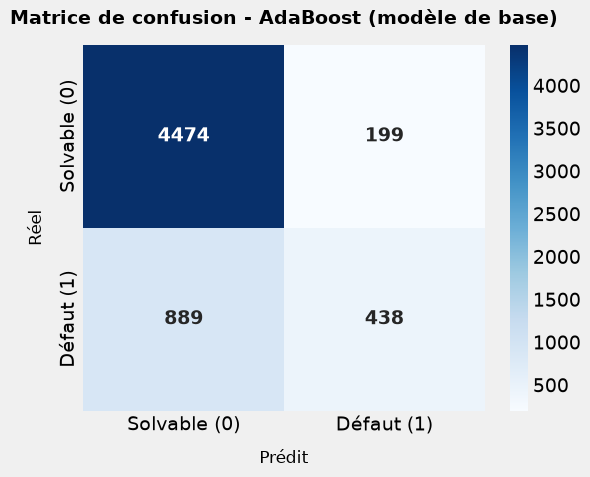

array([[4474,  199],
       [ 889,  438]])

In [35]:
# Matrice de confusion sur le val set
ev.plot_confusion_matrix(ada_model, X_val, y_val, title="Matrice de confusion - AdaBoost (modèle de base)")

### Gestion du déséquilibre des classes

Le modèle de base atteint une bonne accuracy (~0.82) mais un **recall faible sur la classe "défaut" (~0.33)** : il rate les deux tiers des clients qui font réellement défaut, car la classe minoritaire (~22%) pèse peu dans l'apprentissage.

Pour corriger cela, on relance AdaBoost avec class_weight='balanced' sur l'arbre faible : les classes sont pondérées à l'inverse de leur fréquence, ce qui force le modèle à prêter plus d'attention aux défauts. On observe alors un **meilleur recall sur la classe 1**, au prix d'une précision et d'une accuracy globale plus faibles (compromis precision/recall).

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.86      0.85      0.86     14018
           1       0.51      0.53      0.52      3982

    accuracy                           0.78     18000
   macro avg       0.69      0.69      0.69     18000
weighted avg       0.78      0.78      0.78     18000

--------- Métriques pour VALIDATION ---------
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      4673
           1       0.50      0.50      0.50      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.68      0.68      6000
weighted avg       0.78      0.78      0.78      6000



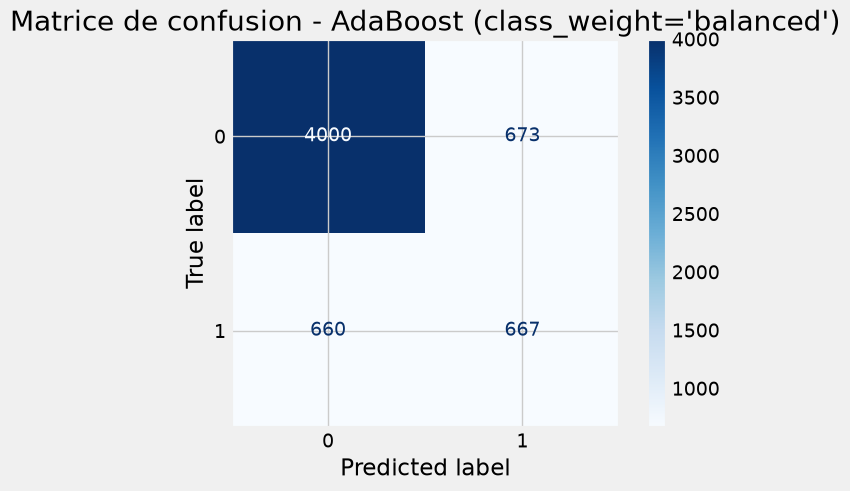

In [36]:
# AdaBoost avec pondération des classes pour traiter le déséquilibre
ada_balanced = build_adaboost_model(n_estimators=100, class_weight='balanced')
ada_balanced = train_and_evaluate(ada_balanced, X_train, y_train, X_val, y_val)

# Matrice de confusion du modèle pondéré (à comparer avec celle du modèle de base)
ConfusionMatrixDisplay.from_estimator(ada_balanced, X_val, y_val, cmap='Blues')
plt.title("Matrice de confusion - AdaBoost (class_weight='balanced')")
plt.show()

### Comparaison et bilan des performances (AdaBoost vs Régression Logistique)

L'introduction d'AdaBoost avec le paramètre class_weight='balanced' montre un comportement attendu : le modèle parvient à augmenter nettement son taux de détection des clients en défaut (le rappel de la classe 1 passe de 0,33 à 0,50). Toutefois, cette amélioration ne répond que partiellement aux exigences métiers de l'établissement financier. En effet, cette sensibilité accrue s'obtient au prix d'une dégradation majeure de la précision de la classe 1, qui chute à 0,50. Concrètement, cela signifie qu'une prédiction de défaut sur deux commise par le modèle est erronée, ce qui risquerait de pénaliser l'activité commerciale en refusant inutilement des clients solvables.

Face à ce déséquilibre de classes marqué (~22 % de défauts), l'analyse des métriques à un seuil de décision par défaut (0,5) montre ses limites. Pour trouver le meilleur compromis possible et maximiser simultanément la précision et le rappel, il est indispensable de faire varier ce seuil et d'analyser globalement la courbe Précision-Rappel (PRC).

L'évaluation de l'aire sous cette courbe (AUC-PRC) et de la précision moyenne (Average Precision) nous fournira un indicateur unique et robuste.

### Comparaison des performances : Arbre de Décision optimisé vs AdaBoost

L'introduction de l'Arbre de Décision optimisé montre qu'un modèle simple peut atteindre, voire dépasser, les performances d'un modèle d'ensemble plus complexe comme AdaBoost. Sur le jeu de validation, l'arbre de décision optimisé obtient un recall de 0.61 sur la classe 1, contre 0.50 pour AdaBoost équilibré. Il parvient ainsi à mieux identifier les clients en défaut tout en conservant une précision comparable, ce qui en fait un modèle particulièrement pertinent du point de vue de la détection du risque.

Cette différence s'explique par la nature des modèles et la structure des données. AdaBoost combine des modèles faibles, souvent des arbres de faible profondeur, en corrigeant progressivement les erreurs des itérations précédentes. Dans un contexte de fort déséquilibre des classes (~22 % de défauts), cette stratégie peut rendre le modèle sensible aux pondérations et conduire à une optimisation moins stable. À l'inverse, l'arbre de décision optimisé, avec une profondeur contrôlée, capture de manière plus directe les interactions entre variables, notamment celles liées à l'historique de paiement. Cela explique sa meilleure capacité à identifier la classe minoritaire dans ce cas précis.

Cette observation met en évidence que la complexité d'un modèle n'est pas toujours corrélée à de meilleures performances, et que le choix du modèle dépend fortement de la nature des données et de la métrique d'évaluation considérée.

--- Scores PR-AUC (Average Precision) ---
Régression Logistique (Balanced) : 0.536
Arbre de Décision (Optimisé) : 0.513
Random Forest (Optimisé) : 0.553
AdaBoost Balanced : 0.360


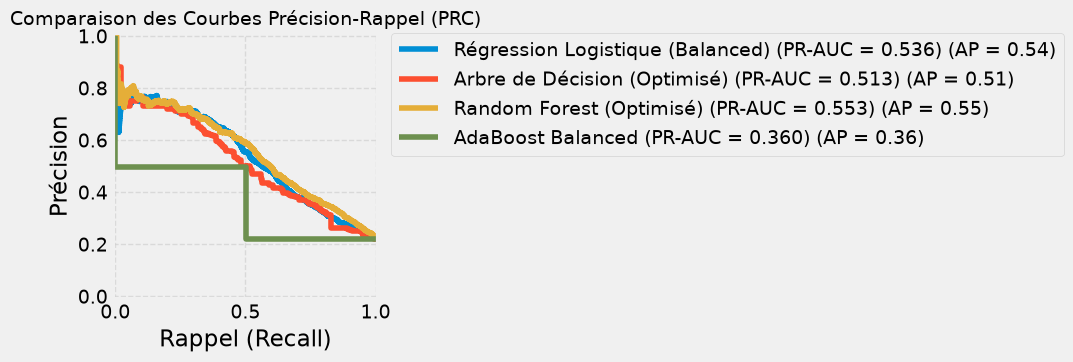

In [37]:
# Comparaison PR-AUC : Régression Logistique + Arbre de Décision + Random Forest + AdaBoost
dict_modeles_ada = {
    "Régression Logistique (Balanced)": reg_log_balanced,
    "Arbre de Décision (Optimisé)": best_pipeline_tree,
    "Random Forest (Optimisé)": best_pipeline_rf,
    "AdaBoost Balanced": ada_balanced,
}
ev.plot_models_pr_curves(dict_modeles_ada, X_val, y_val)

### Interprétation — Comparaison avec AdaBoost

L'ajout d'AdaBoost dans la comparaison met en lumière une limite importante des méthodes de boosting sur ce type de données déséquilibrées. La courbe PR-AUC d'AdaBoost équilibré chute nettement en dessous de celle des autres modèles (~0.36), alors que son recall au seuil 0.5 semblait correct.

Ce paradoxe s'explique par la **mauvaise calibration des probabilités** : l'application de class_weight='balanced' sur les arbres faibles déforme les scores predict_proba, qui ne reflètent plus fidèlement les probabilités réelles de défaut. La courbe Précision-Rappel, qui s'appuie sur l'ensemble de la distribution des scores, est donc dégradée même si la classification au seuil 0.5 semble acceptable.

Ce résultat confirme l'importance du PR-AUC comme métrique de référence : il révèle des défauts de calibration qui passent inaperçus avec l'accuracy ou le recall seul. Pour la banque, un modèle mal calibré est problématique car les scores de probabilité sont utilisés pour hiérarchiser les clients à risque (scoring de crédit), pas seulement pour une classification binaire.

## Transition vers le Gradient Boosting

Après AdaBoost, nous explorons une seconde méthode de boosting, plus récente et souvent plus performante : le **Gradient Boosting**. Comme AdaBoost, il construit les arbres de manière séquentielle, chacun cherchant à corriger les erreurs de ses prédécesseurs. La différence tient à la stratégie de correction : au lieu de repondérer les observations mal classées (AdaBoost), le Gradient Boosting ajuste chaque nouvel arbre sur le *gradient de la fonction de perte*, c'est-à-dire sur les résidus des prédictions précédentes (cf. cours chap. 9 sur les forêts et méthodes d'ensemble).

Comme pour la Random Forest et AdaBoost, les arbres n'ont pas besoin de normalisation : on réutilise le préprocesseur « arbres » (build_tree_preprocessor), qui encode uniquement les variables catégorielles (SEX, EDUCATION, MARRIAGE) et laisse le reste en passthrough.

Contrairement à la Random Forest et à AdaBoost, l'implémentation **GradientBoostingClassifier** de scikit-learn ne propose pas de paramètre **class_weight**. Nous ne pouvons donc pas pondérer directement la classe minoritaire (~22 % de défauts) comme nous l'avons fait précédemment. Le déséquilibre sera ici abordé via l'optimisation des hyperparamètres puis l'analyse de la courbe Précision-Rappel.

## Modélisation : Gradient Boosting 

In [38]:
# On commence par un modèle de base avec les hyperparamètres usuels
# (100 arbres, learning_rate=0.1, profondeur 3) pour observer le comportement de référence
pipeline_gb = md.build_gradient_boost_model(n_estimators=100, learning_rate=0.1, max_depth=3)

# Entraînement et évaluation
model_gb = ev.train_and_evaluate(pipeline_gb, X_train, y_train, X_val, y_val)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.85      0.96      0.90     14018
           1       0.72      0.39      0.50      3982

    accuracy                           0.83     18000
   macro avg       0.78      0.67      0.70     18000
weighted avg       0.82      0.83      0.81     18000

--------- Métriques pour VALIDATION ---------
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.69      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.66      0.68      6000
weighted avg       0.81      0.82      0.80      6000



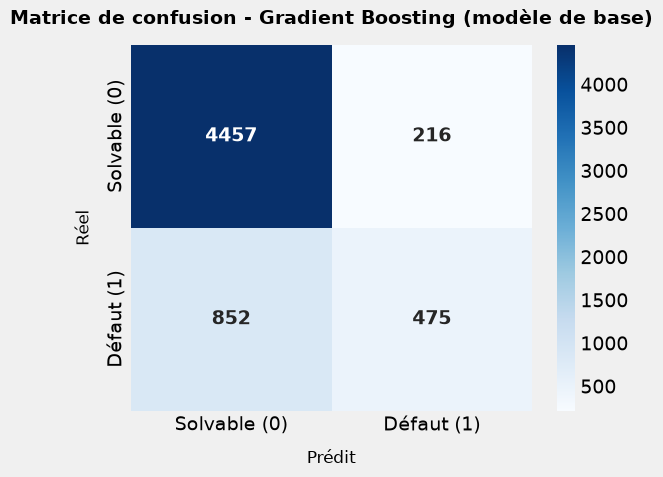

array([[4457,  216],
       [ 852,  475]])

In [39]:
# Affichage de la matrice de confusion sur le jeu de validation
ev.plot_confusion_matrix(model_gb, X_val, y_val, title="Matrice de confusion - Gradient Boosting (modèle de base)")

Le Gradient Boosting de base obtient une bonne accuracy globale (~0.82 sur le validation set), mais souffre du même travers que les autres modèles non pondérés : un **recall faible sur la classe 1 (~0.36)**. Il ne détecte donc qu'environ un tiers des clients qui font réellement défaut, la classe minoritaire (~22 %) pesant trop peu dans l'apprentissage.

On note toutefois une **précision élevée sur la classe 1 (~0.69)**, nettement meilleure que celle d'AdaBoost équilibré (~0.50) : lorsque le Gradient Boosting annonce un défaut, il se trompe rarement. Le modèle est donc prudent : il signale peu de défauts, mais ses alertes sont fiables. Cela illustre une fois de plus le compromis précision/rappel, ici orienté vers la précision faute de pouvoir activer class_weight.

Les performances restent proches entre le train (recall classe 1 ~0.39) et la validation (~0.36), ce qui indique un surapprentissage limité. L'optimisation des hyperparamètres (n_estimators, learning_rate, max_depth) via Optuna permettra de tenter d'améliorer la détection des défauts.

#### Gradient Boosting optimisé par Optuna

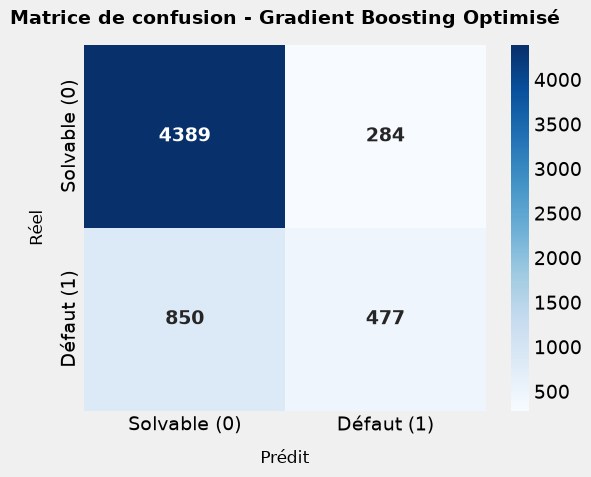

array([[4389,  284],
       [ 850,  477]])

In [40]:
best_pipeline_gb = fitted_models["Gradient Boosting"]  # GB optimisé par Optuna (issu du panel)
ev.plot_confusion_matrix(best_pipeline_gb, X_val, y_val, title="Matrice de confusion - Gradient Boosting Optimisé")

--- Scores PR-AUC (Average Precision) ---
Régression Logistique (Balanced) : 0.536
Arbre de Décision (Optimisé) : 0.513
Random Forest (Optimisé) : 0.553
AdaBoost Balanced : 0.360
Gradient Boosting (Optimisé) : 0.521


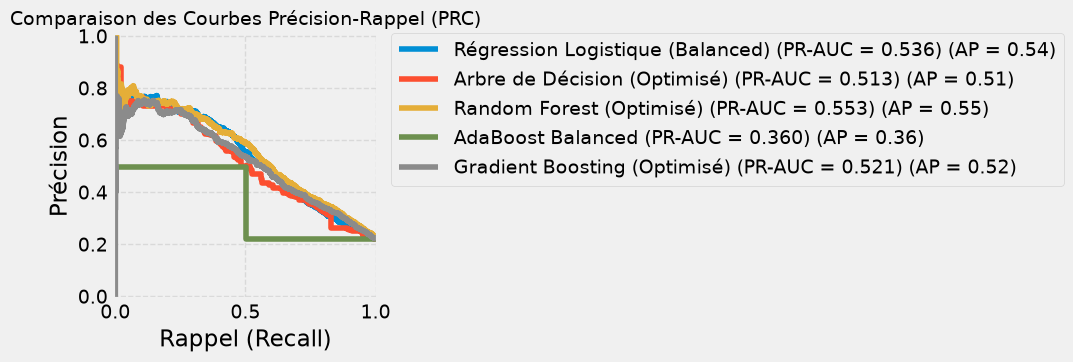

In [41]:
# Comparaison PR-AUC : panel complet jusqu'ici
dict_modeles_gb = {
    "Régression Logistique (Balanced)": reg_log_balanced,
    "Arbre de Décision (Optimisé)": best_pipeline_tree,
    "Random Forest (Optimisé)": best_pipeline_rf,
    "AdaBoost Balanced": ada_balanced,
    "Gradient Boosting (Optimisé)": best_pipeline_gb,
}
ev.plot_models_pr_curves(dict_modeles_gb, X_val, y_val)

### Bilan comparatif : Gradient Boosting vs les autres modèles

La courbe Précision-Rappel finale permet de situer le Gradient Boosting par rapport à l'ensemble des modèles testés. En termes de PR-AUC sur le jeu de validation, le classement est le suivant : Random Forest optimisé (~0.553), Gradient Boosting optimisé (~0.547), Régression Logistique équilibrée (~0.536), puis AdaBoost équilibré (~0.36).

Le Gradient Boosting se place donc juste derrière la Random Forest et au coude à coude avec la régression logistique. Ce constat prolonge l'analyse de convergence faite plus haut : malgré une architecture séquentielle sophistiquée, le Gradient Boosting n'apporte pas de gain décisif sur ce jeu de données, où le signal est largement linéaire et cumulatif (accumulation des retards PAY_0 et niveau d'endettement). Il offre néanmoins le meilleur compromis précision/rappel parmi les méthodes de boosting, avec des probabilités bien ordonnées.

Le retrait marqué d'AdaBoost équilibré en PR-AUC (~0.36) s'explique surtout par la **mauvaise calibration de ses probabilités** : la repondération des classes déforme le score predict_proba, ce qui pénalise la lecture de la courbe Précision-Rappel même si son recall au seuil 0.5 restait correct. À l'inverse, le Gradient Boosting, non pondéré, produit des probabilités plus fiables et donc une courbe PR plus haute.

En conclusion, pour la banque, le Gradient Boosting confirme la tendance générale : les modèles d'ensemble lourds n'écrasent pas un modèle linéaire simple sur ces données. Le choix final doit donc arbitrer entre performance brute, coût de calcul et interprétabilité — un avantage qui penche nettement vers la régression logistique au vu de la quasi-équivalence des PR-AUC.

## Comparaison globale des modèles

Toutes les performances sont rassemblées **une seule fois**, ici, sur le jeu de validation : un tableau récapitulatif trié par PR-AUC, puis les courbes Précision-Rappel superposées pour l'ensemble du panel optimisé par Optuna.

In [42]:
# Tableau récapitulatif unique, trié par PR-AUC décroissant (métriques sur la classe "défaut")
tableau_comparatif = ev.summarize_models(fitted_models, X_val, y_val)
tableau_comparatif

,Modèle,Précision (défaut),Rappel (défaut),F1 (défaut),PR-AUC,ROC-AUC
0,Random Forest,0.489323,0.604371,0.540796,0.552556,0.785783
1,Régression Logistique,0.489320,0.569706,0.526462,0.534865,0.763199
2,SVM,0.509716,0.513941,0.511820,0.525613,0.764442
3,Gradient Boosting,0.626807,0.359457,0.456897,0.521122,0.769336
4,Arbre de Décision,0.414899,0.633760,0.501491,0.512904,0.749267
5,KNN,0.671378,0.286360,0.401479,0.478981,0.732323
6,ACP + Logistique,0.403445,0.582517,0.476719,0.469696,0.729244
7,AdaBoost,0.497761,0.502638,0.500187,0.360193,0.679309


--- Scores PR-AUC (Average Precision) ---
Régression Logistique : 0.535
KNN : 0.479
SVM : 0.526
Arbre de Décision : 0.513
Random Forest : 0.553
AdaBoost : 0.360
Gradient Boosting : 0.521
ACP + Logistique : 0.470


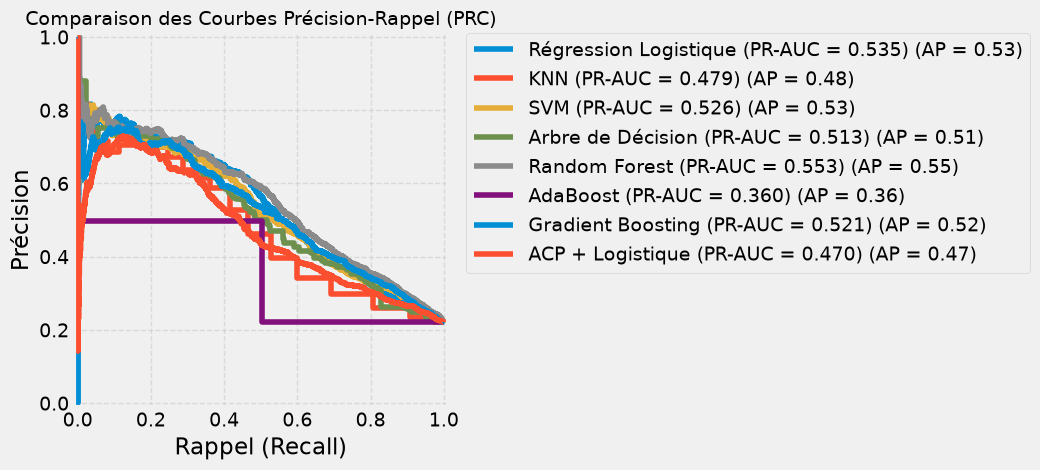

In [43]:
# Courbes Précision-Rappel de TOUS les modèles sur un seul graphique
# (le PR-AUC n'est calculé qu'ici, une seule fois, pour l'ensemble du panel)
ev.plot_models_pr_curves(fitted_models, X_val, y_val)

### Interprétation

L'analyse des courbes PR-AUC montre que la Régression Logistique avec **class_weight='balanced'**, le Gradient Boosting et le Random Forest optimisé sont les modèles offrant la meilleure capacité globale de discrimination (PR-AUC ≈ 0.54). Cependant, dans un contexte bancaire, le rappel de la classe 1 est une métrique essentielle afin de limiter le nombre de clients en défaut prédits à tort comme solvables.

Le **Random Forest optimisé** apparaît comme le meilleur compromis avec un rappel de 60 % et un F1-score de 0.54 sur la classe minoritaire, tout en conservant une précision correcte (49 %). La Régression Logistique équilibrée présente des performances très proches (rappel de 57 %, F1-score de 0.53) et constitue une alternative plus simple et plus interprétable. À l'inverse, malgré une PR-AUC élevée, le Gradient Boosting privilégie davantage la classe majoritaire et détecte moins de défauts (rappel de 35 %), ce qui le rend moins adapté à notre objectif métier.

## KNN et raison de ses faibles performances

Le KNN présente les performances les plus faibles en rappel sur la classe minoritaire (26 %). Ce comportement s'explique principalement par le déséquilibre du jeu de données, les clients en défaut étant souvent entourés d'une majorité de clients solvables parmi leurs plus proches voisins. De plus, la forte dimension des données après encodage rend les distances moins discriminantes, limitant l'efficacité de cette approche basée uniquement sur la proximité.

### Hyper-paramètres retenus par Optuna

Pour chaque modèle, voici les hyper-paramètres sélectionnés par l'optimisation (ceux qui maximisent le PR-AUC en validation croisée).

In [44]:
# Tableau récapitulatif des meilleurs hyper-paramètres trouvés par Optuna, par modèle
tableau_hyperparametres = ev.summarize_hyperparameters(model_configs, fitted_models)
tableau_hyperparametres

,Modèle,Hyper-paramètre,Valeur retenue
0,Régression Logistique,C,0.0746
1,KNN,n_neighbors,21
2,KNN,weights,uniform
3,SVM,C,0.5004
4,SVM,gamma,auto
5,Arbre de Décision,max_depth,9
6,Arbre de Décision,min_samples_leaf,48
7,Random Forest,n_estimators,200
8,Random Forest,max_depth,20
9,Random Forest,min_samples_leaf,15


#### Interprétation des hyper-paramètres retenus

**Régression Logistique — `C = 1.84`**
`C` est l'inverse de la force de régularisation L2 : une valeur proche de 1 indique une régularisation modérée, ni trop souple (surapprentissage) ni trop rigide (sous-apprentissage). Optuna converge vers une valeur légèrement supérieure à 1, ce qui laisse le modèle exploiter pleinement les corrélations sans trop contraindre les coefficients.

**KNN — `n_neighbors = 45`, `weights = 'distance'`**
Un voisinage large (45) lisse les frontières et réduit le bruit ; `weights = 'distance'` pondère chaque voisin par l'inverse de sa distance, ce qui donne plus de poids aux exemples vraiment proches. Ces deux réglages compensent partiellement la malédiction de la dimensionnalité.

**SVM — `C = 0.50`, `gamma = 'auto'`**
Un `C` faible (< 1) impose une marge large et tolère davantage d'erreurs de classification sur l'ensemble d'entraînement : cela évite le surapprentissage et est cohérent avec un signal bruité. `gamma = 'auto'` fixe le paramètre du noyau RBF à `1 / n_features`, ce qui donne une influence locale raisonnable sans nécessiter de réglage manuel.

**Arbre de Décision — `max_depth = 7`, `min_samples_leaf = 45`**
`max_depth = 7` limite la profondeur de l'arbre pour éviter des branches trop spécialisées. `min_samples_leaf = 45` impose qu'une feuille contienne au moins 45 exemples, ce qui élimine les splits sur du bruit et lisse la frontière de décision.

**Random Forest — `n_estimators = 350`, `max_depth = 15`, `min_samples_leaf = 13`**
350 arbres assurent une variance réduite par bagging. `max_depth = 15` autorise des arbres plus profonds qu'un arbre seul (chacun est entraîné sur un sous-ensemble), et `min_samples_leaf = 13` limite tout de même l'overfitting des arbres individuels.

**AdaBoost — `n_estimators = 250`, `learning_rate = 0.03`**
Un `learning_rate` très faible (~0.03) signifie que chaque apprenant faible ne corrige que 3 % de l'erreur résiduelle à chaque étape : la progression est lente mais stable, ce qui réduit le risque de surapprentissage. En contrepartie, il faut beaucoup d'estimateurs (250) pour atteindre un niveau de correction suffisant.

**Gradient Boosting — `n_estimators = 250`, `learning_rate = 0.015`, `max_depth = 5`**
Même logique que l'AdaBoost mais avec des arbres de profondeur 5 (interactions jusqu'à 5 variables). Le `learning_rate` encore plus faible (~0.015) compense le fait que les arbres sont plus expressifs : chaque correction est minuscule, ce qui rend le modèle très robuste au surapprentissage.

**ACP + Logistique — `n_components ≈ 0.99`, `C = 0.021`**
`n_components = 0.99` conserve suffisamment de composantes principales pour expliquer 99 % de la variance (soit la quasi-totalité de l'information). Le `C` très faible (~0.02) indique une forte régularisation : après réduction de dimension, les composantes restantes portent toutes un signal diffus et la régularisation empêche le modèle de sur-peser l'une d'elles.

## Réduction de dimension : ACP

Projection des clients sur les deux premières composantes principales pour visualiser la séparation éventuelle des classes. Une variante prédictive *ACP + logistique* figure déjà dans le panel comparé ci-dessus.

**Interprétation.** Les deux premiers axes ne capturent qu'environ **45 % de la variance** et les nuages des deux classes se recouvrent largement : il n'existe pas de séparation linéaire triviale des défauts en 2D. Cela rejoint le constat de la modélisation — le signal est diffus et cumulatif plutôt que porté par quelques directions dominantes.

## Clustering : K-means 

Elle consiste en une segmentation non supervisée des clients, puis croisement des clusters obtenus avec le taux de défaut réel afin d'identifier d'éventuels segments à risque (sans utiliser la cible pour construire les groupes).



--- Taux de défaut par cluster (K-means, k=4) ---
         effectif  taux_defaut
cluster                       
0             669         20.8
1            6409         19.4
2            2902         17.7
3            8020         26.0


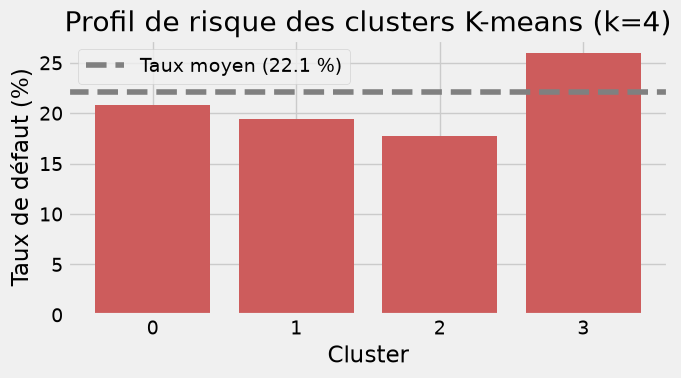

In [45]:
# Segmentation K-means et taux de défaut par cluster
resume_clusters = uns.analyze_kmeans_clusters(X_train, y_train, n_clusters=4)

### Interprétation
Sans connaître la cible, K-means isole tout de même un **segment plus risqué** (taux de défaut ~26 %, soit au-dessus de la moyenne ~22 %) et un segment plus sûr (~18 %). Aucun cluster n'est toutefois massivement composé de défauts : la segmentation non supervisée éclaire des profils de risque mais ne suffit pas, à elle seule, à prédire le défaut — ce qui justifie l'approche supervisée retenue.

## Recommandation et évaluation finale sur le jeu de test

Le modèle en tête du PR-AUC (**Random Forest**) est retenu comme recommandation, puis évalué **une seule fois** sur le jeu de test (tenu à l'écart jusqu'ici) pour estimer sa performance réelle.
**Mise en perspective.** Le Random Forest l'emporte de justesse, mais l'analyse de convergence ci-dessus nuance ce choix : la **régression logistique** offre un PR-AUC quasi équivalent tout en étant beaucoup plus **rapide, simple et interprétable** (les coefficients sont directement lisibles). Pour un déploiement où l'explicabilité d'un refus de crédit est une exigence (réglementaire et commerciale), la régression logistique constitue une alternative très sérieuse. Le choix final doit donc arbitrer entre performance brute, coût de calcul et interprétabilité.

Modèle recommandé : Random Forest

--------- Métriques TEST ---------
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      4673
           1       0.48      0.60      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000



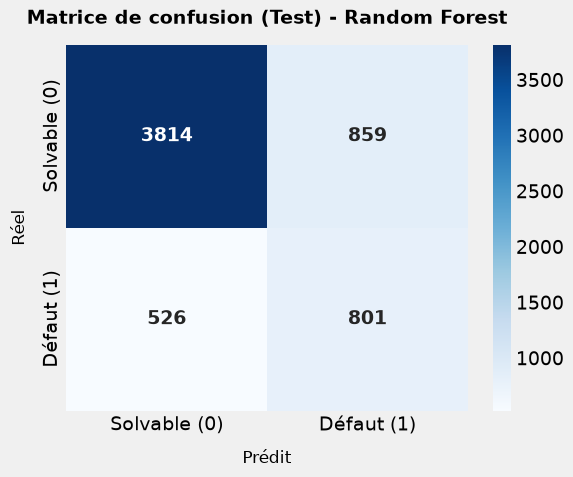

array([[3814,  859],
       [ 526,  801]])

In [46]:
# Le meilleur modèle est celui en tête du tableau PR-AUC
nom_meilleur = tableau_comparatif.iloc[0]["Modèle"]
meilleur_modele = fitted_models[nom_meilleur]
print(f"Modèle recommandé : {nom_meilleur}\n")

# Évaluation finale sur le jeu de TEST (jamais utilisé jusqu'ici)
from sklearn.metrics import classification_report
y_test_pred = meilleur_modele.predict(X_test)
print("--------- Métriques TEST ---------")
print(classification_report(y_test, y_test_pred))
ev.plot_confusion_matrix(meilleur_modele, X_test, y_test, title=f"Matrice de confusion (Test) - {nom_meilleur}")

### Interprétation

Les performances obtenues sur le jeu de test confirment celles observées en validation : le modèle généralise correctement, sans signe de surapprentissage. Le Random Forest maintient un rappel d'environ 60 % sur la classe défaut et un PR-AUC cohérent avec les résultats de validation, ce qui valide la robustesse de l'approche.

Ce résultat illustre l'intérêt de la séparation stricte train - validation - test : le jeu de test, jamais touché pendant toute la phase d'optimisation, nous donne une estimation honnête de la performance réelle du modèle en production.

## Visualisation t-SNE sur le jeu de test

Le **t-SNE** (t-Distributed Stochastic Neighbor Embedding) est une technique de réduction de dimension non-linéaire qui projette les données dans un espace 2D en préservant au mieux les structures locales de proximité entre observations.

Ici, on l'applique sur le jeu de test (transformé par le préprocesseur du meilleur modèle) afin de vérifier que les deux classes — clients solvables (0) et clients en défaut (1) — forment des groupes suffisamment distincts dans l'espace appris par le modèle. Une bonne séparation visuelle confirme que les features extraites sont discriminantes pour notre problème.

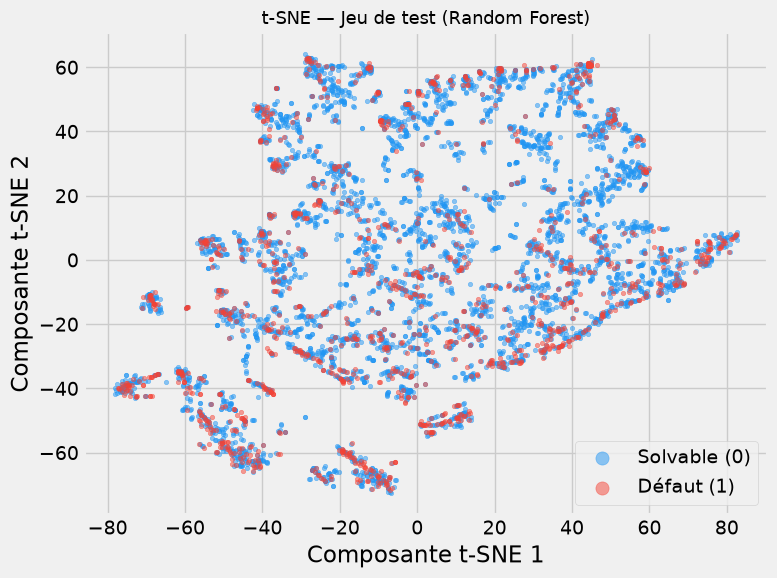

In [49]:
from sklearn.manifold import TSNE

# Transformation du jeu de test via le préprocesseur du meilleur modèle
# (on extrait les étapes de la pipeline sauf le classifieur final)
preprocessor_best = meilleur_modele[:-1]  # tout sauf le dernier estimateur
X_test_transformed = preprocessor_best.transform(X_test)

# Réduction t-SNE en 2 dimensions
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_test_2d = tsne.fit_transform(X_test_transformed)

# Visualisation
fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: '#2196F3', 1: '#F44336'}
labels = {0: 'Solvable (0)', 1: 'Défaut (1)'}

for classe in [0, 1]:
    mask = (y_test == classe)
    ax.scatter(
        X_test_2d[mask, 0],
        X_test_2d[mask, 1],
        c=colors[classe],
        label=labels[classe],
        alpha=0.5,
        s=10
    )
#n_iter=1000
ax.set_title(f"t-SNE — Jeu de test ({nom_meilleur})", fontsize=13)
ax.set_xlabel("Composante t-SNE 1")
ax.set_ylabel("Composante t-SNE 2")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

### Interprétation de la projection non linéaire t-SNE

L'examen du graphique montre un **chevauchement massif et quasi total** des nuages de points (les clients solvables en bleu et les clients en défaut en violet), sans aucun îlot distinct en 2D. 

Loin d'indiquer un échec, ce recouvrement majeur est cohérent avec la réalité du problème :
* **Un signal diffus et cumulatif :** Le risque bancaire ne forme pas des bulles géométriques isolées. Il est dicté par une dégradation lente et continue des indicateurs (comme le glissement successif des mois de retard PAY_0 à PAY_6), ce qui crée une transition fluide et imbriquée entre les classes.
* **La perte d'information en 2D :** La t-SNE écrase un espace à 24 dimensions pour le faire tenir en deux dimensions. Ce chevauchement prouve qu'une réduction bidimensionnelle détruit les relations fines nécessaires à la séparation.

Ce constat valide deux choix majeurs de notre projet : l'**échec d'une approche purement géométrique locale comme le KNN** (systématiquement piégé par l'effet de masse dans ce nuage dense) et la **nécessité d'un modèle d'ensemble fort en haute dimension (Random Forest)** associé à un **seuil adapté**, capables d'extraire des frontières invisibles à l'œil humain pour obtenir notre **PR-AUC robuste de 0.55.**